**Flugticket-Kaufempfehlungen**

   Desiree Possi 580239

Problemstellung

Ziel dieses Projekts ist es, ein datengetriebenes Entscheidungsmodell zu entwickeln,
das Kund:innen bei der Frage unterstützt, ob ein Flugticket zum aktuellen Zeitpunkt
gekauft werden sollte oder ob es sinnvoll ist, auf einen möglicherweise niedrigeren
Preis zu warten.

Jede Zeile des Datensatzes wird als einzelne Preisanfrage interpretiert.
Der Trainingsdatensatz enthält zusätzlich Zukunftsinformationen, die zur Modellbildung
verwendet werden dürfen, während der Testdatensatz eine reale Anwendungssituation
ohne diese Informationen simuliert.


1. Importieren der Bibliotheken

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, confusion_matrix


2. Datensatzübersicht


In [4]:
train = pd.read_csv('train_set.csv', parse_dates=['Request_Date', 'Flight_Date'])
test = pd.read_csv('test_set.csv', parse_dates=['Request_Date', 'Flight_Date'])
# Erste Übersicht
print(train.head())
print(train.info())
print(train.describe())

   index              Request_Date Flight_Date  Departure_hour  \
0      1 2019-06-03 11:00:00+00:00  2019-06-05              19   
1      2 2019-06-03 23:00:00+00:00  2019-06-05              19   
2      3 2019-06-04 11:00:00+00:00  2019-06-05              19   
3      4 2019-06-04 23:00:00+00:00  2019-06-05              19   
4      5 2019-06-03 11:00:00+00:00  2019-06-05              21   

    flight_unique_id route_abb  Price_In_Eur  min_future_price_in_Eur  buy  
0  2019-06-05 FR 146   SXF-STN        208.07                   259.07    1  
1  2019-06-05 FR 146   SXF-STN        259.07                   259.07    1  
2  2019-06-05 FR 146   SXF-STN        259.07                   259.07    1  
3  2019-06-05 FR 146   SXF-STN        259.07                   259.07    1  
4  2019-06-05 FR 147   STN-SXF        143.86                   251.72    1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83624 entries, 0 to 83623
Data columns (total 9 columns):
 #   Column                   Non

BESCHREIBUNG DER ERGEBNISSE:

Der Trainingsdatensatz umfasst 83 624 Beobachtungen mit insgesamt 9 Merkmalen.
Jede Zeile beschreibt eine einzelne Preisanfrage für einen konkreten Flug zu einem
bestimmten Zeitpunkt.
Die Merkmale lassen sich in zeitliche Variablen (Request_Date, Flight_Date),
flugbezogene Informationen (flight_unique_id, route_abb, Departure_hour) sowie
preisbezogene Variablen (Price_In_Eur, min_future_price_in_Eur) einteilen.
Die Zielvariable `buy` ist binär kodiert.

- Zeitlicher Umfang der Daten: Die betrachteten Flüge liegen im Zeitraum von Anfang Juni bis Mitte September 2019.
Der Median des Flugdatums liegt Anfang August, was auf einen starken Fokus auf die
Sommerreisesaison hindeutet.

- Abflugzeiten: Die Abflugszeiten liegen zwischen 6 und 22 Uhr.
Der Median liegt bei 10 Uhr, während ein weiterer Schwerpunkt auf Abendflügen
zu erkennen ist. Dies deutet auf eine nicht gleichmäßige Verteilung der Abflugzeiten hin.

- Preisverteilung: Die Flugpreise weisen eine große Spannweite auf und reichen von unter 10 Euro bis
zu über 370 Euro. Der Medianpreis liegt bei rund 55 Euro, während der Mittelwert
mit etwa 72 Euro deutlich höher ist.

- Klassenverteilung der Zielvariable: Da die Zielvariable `buy` binär kodiert ist (1 = kaufen, 0 = warten), entspricht
der Mittelwert dieser Variable dem Anteil der Fälle, in denen ein sofortiger Kauf
optimal gewesen wäre. Mit einem Mittelwert von rund 0,22 zeigt sich, dass nur etwa
22 % der Preisanfragen zu einem sofortigen Kauf hätten führen sollen.  Mittelwert =Anzahl der 1en/Anzahl Beobachtungen


3. Deskriptive Analyse

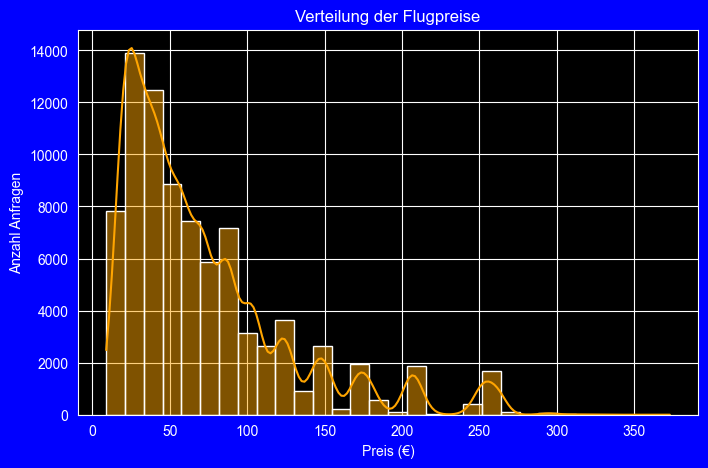

In [25]:
# a) Verteilungen
plt.figure(figsize=(8,5),facecolor="blue")
sns.histplot(train['Price_In_Eur'], bins=30, color="orange", kde = True)
plt.title("Verteilung der Flugpreise")
plt.xlabel("Preis (€)")
plt.ylabel("Anzahl Anfragen")
plt.show()




**Beschreibung**
Die Histogramm- und KDE-Darstellung zeigt die Verteilung der Flugpreise (`Price_In_Eur`). Die Verteilung ist stark rechtsschief (positiv schief).

**Interpretation**
- Der Großteil der Flugpreise liegt im Bereich von ca. 20 € bis 80 €.
- Es gibt wenige, aber sehr hohe Preise (bis über 350 €), die als Ausreißer auftreten.
- Die rechtsschiefe Verteilung ist typisch für Preisdaten und deutet darauf hin, dass günstige Preise häufig vorkommen, sehr teure Flüge selten, aber möglich sind.

**Erkenntnisse**
- Der Preis ist kein normalverteilter Wert → Modelle wie lineare Regression müssen ggf. robust oder transformiert werden.
- Hohe Preise könnten eine wichtige Rolle bei der Kaufentscheidung spielen.
- Für die Klassifikation (`buy`) ist zu erwarten, dass mit steigenden Preisen die Kaufwahrscheinlichkeit sinkt.


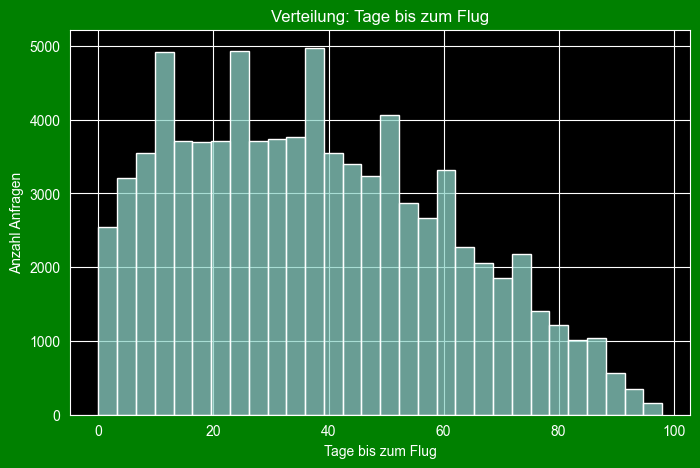

In [31]:
# b) days_to_flight
# Verteilung der Tage bis zum Flug (days_to_flight)
train['Request_Date'] = pd.to_datetime(train['Request_Date'], utc=True).dt.tz_localize(None)
train['Flight_Date'] = pd.to_datetime(train['Flight_Date'])

# b) days_to_flight
train['days_to_flight'] = (train['Flight_Date'] - train['Request_Date']).dt.days

# negative Werte absichern
train['days_to_flight'] = train['days_to_flight'].clip(lower=0)

# Visualisierung
plt.figure(figsize=(8,5),facecolor="green")
sns.histplot(train['days_to_flight'], bins=30, kde=False)
plt.title("Verteilung: Tage bis zum Flug")
plt.xlabel("Tage bis zum Flug")
plt.ylabel("Anzahl Anfragen")
plt.show()



**Beschreibung**
Das Histogramm zeigt die Verteilung der Anzahl der Tage zwischen Anfrage- und Flugdatum.

**Interpretation**
- Anfragen verteilen sich über einen Zeitraum von 0 bis ca. 100 Tagen vor Abflug.
- Die meisten Anfragen erfolgen zwischen 10 und 50 Tagen vor dem Flug.
- Mit zunehmender Zeit bis zum Flug nimmt die Anzahl der Anfragen ab.

**Erkenntnisse**
- `days_to_flight` ist ein sehr relevantes Feature, da Flugpreise typischerweise zeitabhängig sind und die Kaufentscheidung stark davon abhängen kann, wie nah der Abflug ist.
- Das Merkmal eignet sich sowohl für Regression (Preisvorhersage) als auch für Klassifikation (Kaufen vs. Warten).


Boxplot Price vs. Route

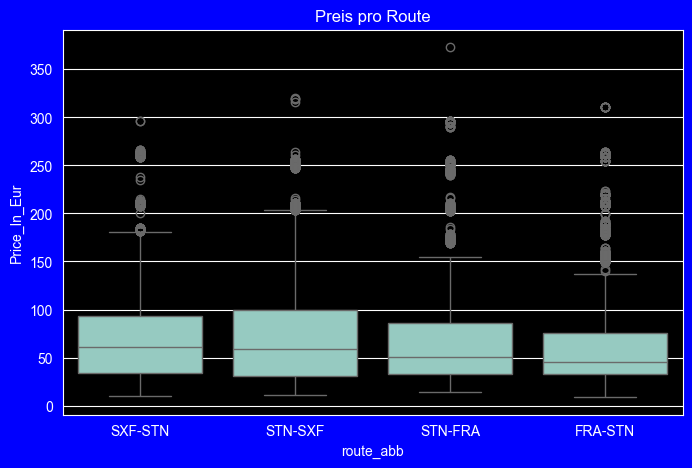

In [34]:
# c) Boxplot Price vs. Route
plt.figure(figsize=(8,5),facecolor="blue")
sns.boxplot(x='route_abb', y='Price_In_Eur', data=train)
plt.title("Preis pro Route")
plt.show()


**Beschreibung**
Der Boxplot vergleicht die Preisverteilungen für verschiedene Flugrouten.

**Interpretation**
- Die Routen unterscheiden sich klar im Preisniveau: Einige Routen (z.B. STN–FRA) weisen höhere Medianpreise und größere Streuungen auf.
- Alle Routen zeigen Ausreißer nach oben, was auf gelegentlich sehr hohe Preise hindeutet.
- Die Interquartilsabstände unterscheiden sich, was auf unterschiedliche Preisdynamiken je Route schließen lässt.

**Erkenntnisse**
- `route_abb` ist ein sehr wichtiges kategoriales Feature.
- Die Preisunterschiede zwischen Routen legen nahe: One-Hot-Encoding oder Target-Encoding für Modelle.
- Modelle sollten Routenspezifika lernen können, da ein globales Modell ohne Route wichtige Information verliert.


Price vs min_future_price_in_Eur

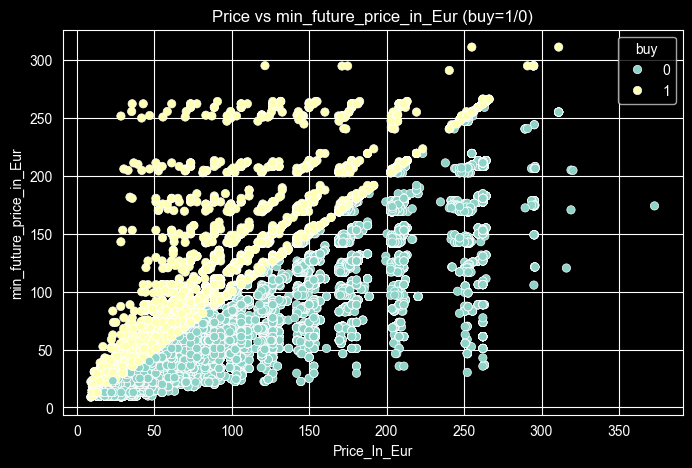

In [35]:
# d) Scatter: Price vs min_future_price_in_Eur
plt.figure(figsize=(8,5))
sns.scatterplot(x='Price_In_Eur', y='min_future_price_in_Eur', hue='buy', data=train)
plt.title("Price vs min_future_price_in_Eur (buy=1/0)")
plt.show()

Avg Price pro Departure_hour und Route

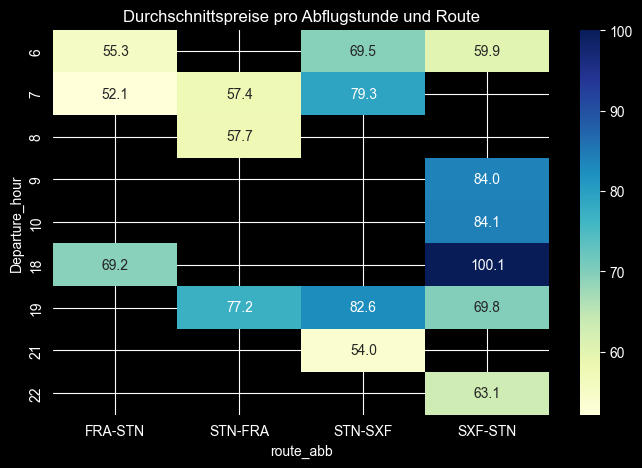

In [36]:
# e) Heatmap: Avg Price pro Departure_hour und Route
pivot = train.pivot_table(index='Departure_hour', columns='route_abb', values='Price_In_Eur', aggfunc='mean')
plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Durchschnittspreise pro Abflugstunde und Route")
plt.show()

4. Feature Engineering

In [39]:
# Zeitfeatures
train['request_month'] = train['Request_Date'].dt.month
train['request_weekday'] = train['Request_Date'].dt.weekday
train['flight_month'] = train['Flight_Date'].dt.month
train['flight_weekday'] = train['Flight_Date'].dt.weekday

# Preisbezogene Features
train['log_price'] = np.log(train['Price_In_Eur'])
route_median = train.groupby('route_abb')['Price_In_Eur'].transform('median')
train['price_relative_to_route_median'] = train['Price_In_Eur'] / route_median

# Features für Modell (Beispiel)
feature_cols = ['Price_In_Eur', 'days_to_flight', 'Departure_hour',
                'request_month', 'request_weekday',
                'flight_month', 'flight_weekday',
                'log_price', 'price_relative_to_route_median']

# Kategoriales Encoding (Departure_hour kann gebinnt werden)
train['Departure_hour_bin'] = pd.cut(train['Departure_hour'], bins=[0,6,12,18,24], labels=False)
feature_cols.append('Departure_hour_bin')

# Target
y_class = train['buy']
y_reg = train['min_future_price_in_Eur']


5. Monetäre Metrik Funktion

In [45]:
def compute_monetary_loss(df, predictions):
    loss = []
    for idx, row in df.iterrows():
        pred = predictions[idx]
        if pred == 1:  # buy
            if row['Price_In_Eur'] <= row['min_future_price_in_Eur']:
                loss.append(0)
            else:
                loss.append(row['Price_In_Eur'] - row['min_future_price_in_Eur'])
        else:  # wait
            if row['Price_In_Eur'] <= row['min_future_price_in_Eur']:
                loss.append(row['min_future_price_in_Eur'] - row['Price_In_Eur'])
            else:
                loss.append(0)
    return np.mean(loss)

6. Klassifikation:  Logistic Regression

In [41]:
X_class = train[feature_cols].fillna(0)
clf = LogisticRegression(max_iter=1000)
clf.fit(X_class, y_class)

# Vorhersage
pred_class = clf.predict(X_class)

# Accuracy & Confusion Matrix
acc = accuracy_score(y_class, pred_class)
cm = confusion_matrix(y_class, pred_class)
monetary_loss = compute_monetary_loss(train, pred_class)

print("Klassifikation Accuracy:", acc)
print("Confusion Matrix:\n", cm)
print("Durchschnittlicher Geldverlust:", round(monetary_loss,2), "€")


Klassifikation Accuracy: 0.7940662967569119
Confusion Matrix:
 [[63355  1551]
 [15670  3048]]
Durchschnittlicher Geldverlust: 1.17 €


## Klassifikation Accuracy
- **Accuracy:** 0.79
Die Klassifikation erreicht eine Genauigkeit von ca. 79 %, d.h. das Modell sagt in etwa 79 % der Fälle korrekt voraus, ob ein Kunde kauft oder nicht.

## Confusion Matrix
|                   | **Predicted: Nicht Kaufen** | **Predicted: Kaufen** |
|-------------------|----------------------------|----------------------|
| **Actual: Nicht Kaufen** | 63.355                     | 1.551                |
| **Actual: Kaufen**       | 15.670                     | 3.048                |

**Interpretation-:**
- Die meisten Nicht-Käufer werden korrekt als Nicht-Käufer klassifiziert (63.355).
- Einige Nicht-Käufer werden fälschlicherweise als Käufer vorhergesagt (1.551).
- Viele tatsächliche Käufer werden vom Modell als Nicht-Käufer falsch klassifiziert (15.670).
- 3.048 Käufer werden korrekt erkannt.

> Das Modell hat eine höhere Genauigkeit bei der Erkennung von Nicht-Käufern als von Käufern, was auf eine **Klassen-Ungleichverteilung** oder ein Ungleichgewicht in den Trainingsdaten hinweisen könnte.

## Durchschnittlicher Geldverlust
- **Monetary Loss:** 1,17 €
Das Modell verursacht im Durchschnitt einen Geldverlust von 1,17 € pro Kunde, wenn falsche Kaufentscheidungen getroffen werden.
Dies ist ein relativ niedriger Wert und deutet darauf hin, dass das Modell wirtschaftlich sinnvoll eingesetzt werden kann.


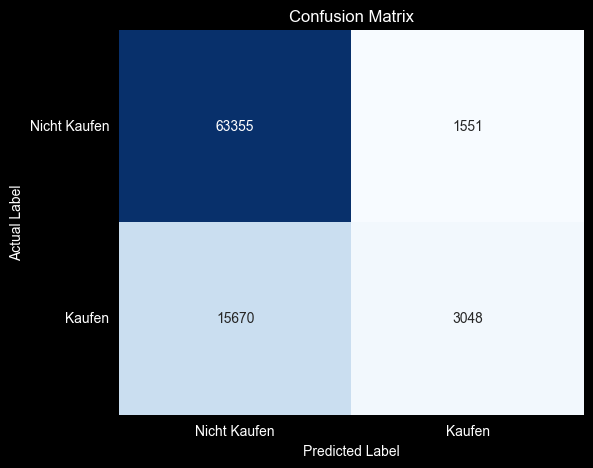

In [48]:
# Confusion Matrix
conf_matrix = np.array(cm)

plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", cbar=False)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0.5, 1.5], ['Nicht Kaufen', 'Kaufen'])
plt.yticks([0.5, 1.5], ['Nicht Kaufen', 'Kaufen'], rotation=0)
plt.show()


7. Regression:  Ridge Regression

In [49]:
X_reg = train[feature_cols].fillna(0)
reg = Ridge()
reg.fit(X_reg, y_reg)

# Vorhersage & Kaufentscheidung ableiten
pred_reg_price = reg.predict(X_reg)
pred_reg_buy = np.where(pred_reg_price >= train['Price_In_Eur'], 1, 0)

# Accuracy & monetäre Bewertung
acc_reg = accuracy_score(y_class, pred_reg_buy)
monetary_loss_reg = compute_monetary_loss(train, pred_reg_buy)

print("Regression-basierte Kaufentscheidung Accuracy:", acc_reg)
print("Durchschnittlicher Geldverlust Regression:", round(monetary_loss_reg,2), "€")


Regression-basierte Kaufentscheidung Accuracy: 0.7834234191141299
Durchschnittlicher Geldverlust Regression: 1.25 €


## Accuracy der Kaufentscheidung
- **Accuracy:** 0.78
Die Ableitung der Kaufentscheidung aus der Ridge-Regression erreicht eine Genauigkeit von ca. 78 %.
Das Modell trifft also in etwa 78 % der Fälle die korrekte Entscheidung, ob ein Kunde kaufen sollte oder nicht.

## Durchschnittlicher Geldverlust
- **Monetary Loss:** 1,25 €
Das Modell verursacht im Durchschnitt einen Geldverlust von 1,25 € pro Kunde, wenn die Kaufentscheidung aufgrund der Preisvorhersage falsch getroffen wird.
Dies ist nur geringfügig höher als bei der direkten Klassifikation, zeigt aber, dass die Regression-basierte Methode wirtschaftlich ebenfalls tragbar ist.

## Interpretation
- Die Accuracy liegt nur leicht unter der direkten Klassifikation (78 % vs. 79 %), was darauf hinweist, dass die Preisprognose der Ridge-Regression für die Ableitung von Kaufentscheidungen gut geeignet ist.
- Der monetäre Verlust ist ebenfalls niedrig und im ähnlichen Bereich wie bei der Klassifikation.
- Vorteil dieser Methode: Man erhält zusätzlich eine **Preisvorhersage**, die für weitere Analysen oder dynamische Preisentscheidungen genutzt werden kann.
- Nachteil: Das Modell kann bei stark schwankenden Preisen oder Ausreißern unter Umständen falsche Kaufentscheidungen ableiten.


8. Visualisierung monetäre Metrik

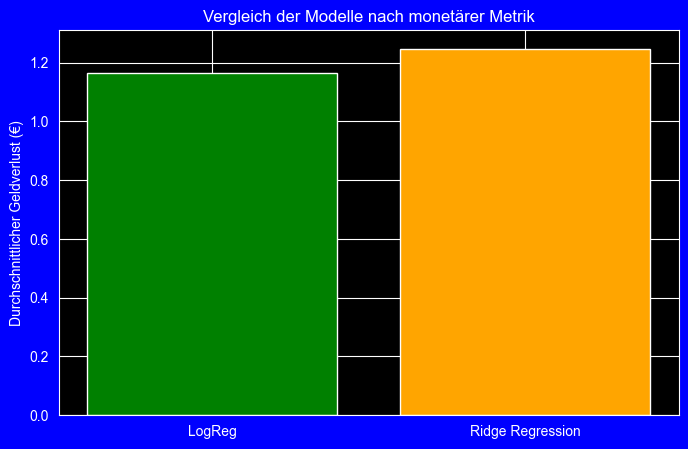

In [44]:
plt.figure(figsize=(8,5),facecolor="blue")
plt.bar(['LogReg', 'Ridge Regression'], [monetary_loss, monetary_loss_reg], color=['green','orange'])
plt.ylabel("Durchschnittlicher Geldverlust (€)")
plt.title("Vergleich der Modelle nach monetärer Metrik")
plt.show()

# Vergleich: Logistische Regression vs. Ridge Regression

## Durchschnittlicher Geldverlust
- **Logistische Regression:** 1,17 €
- **Ridge Regression (preisbasiert):** 1,25 €

**Interpretation:**
- Die Ridge Regression verursacht im Durchschnitt einen leicht höheren Geldverlust (+0,08 € pro Kunde) im Vergleich zur direkten Klassifikation mit logistischer Regression.
- Grund dafür ist, dass die Kaufentscheidung bei der Ridge Regression indirekt über die Preisvorhersage abgeleitet wird.
  - Wenn die prognostizierten Preise die tatsächlichen Preise unterschätzen oder überschätzen, kann das zu **falschen Kaufentscheidungen** führen.
- Die Logistische Regression ist direkt auf die Kaufentscheidung trainiert, sodass sie im Mittel **präzisere Entscheidungen** in Bezug auf Kauf/Nicht-Kauf trifft.
- Die Differenz ist jedoch **relativ gering**, was darauf hindeutet, dass die Ridge Regression ökonomisch fast genauso effizient ist.

**Schlussfolgerung:**
- Für reine Kaufentscheidungen ist die Logistische Regression leicht vorteilhafter.
- Wenn zusätzlich **Preisvorhersagen** benötigt werden, ist die Ridge Regression sinnvoll, da der geringe Anstieg im Geldverlust wirtschaftlich akzeptabel ist.
